# Assignment 1 - Reproducible Notebook

# WQD7013_G7_Stats
- **Course:** WQD7013 STATISTICS FOR DATA SCIENCE
- **Dataset:** Global Air Quality 2023 (Messy from WAQI786) 
- **Group Members:**

| No. | Name | Student ID |
|-----|------|------------|
|1|Nurin Miza Afiqah Binti Andrie Dazlee|s2154141|
|2|Anisah Maisarah Binti Ahmad Nasaruddin|S2121975|
|3|Ng Jing Lee|24215833|
|4|Nur Aliah Natasya|25085928|
|5|Pan Hui Xin|25090880|
|6|Mohd Khairi Bin Yusof|S2191607|

This notebook follows reproducibility rules (no absolute paths).

### This dataset contains global air quality observations:

- **Air quality measurements**: `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`  
- **Meteorological data**     : `Temperature`, `Humidity`, `Wind Speed`  
- **Location information**    : `City` and `Country`  
- **Temporal data**           : `Date of observation`
- **Colunm added**              : `AQI_level`, `AQI_Category`, `PM2.5_Category`, `PM25_Level`, `PM10_Level`, `Year`, `Month` and `Temp_Category` 

# Setup & Library Imports 

We import the core libraries used throughout the notebook: `pandas` and `numpy` for data handling..... ## please add relevant packages ##

In [1]:
# Make sure your dataset is in the same folder as this notebook
#Core
import pandas as pd
import numpy as np

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Dataset path
file_path = 'global_air_quality.csv'
kaggle_source = 'https://www.kaggle.com/datasets/coffxc12/global-air-quality-2023-messy-from-waqi786/data'

#Formating 
pd.options.display.float_format = '{:.3f}'.format


---
# Task A Dataset Audit and Variable Classification

### A1.1 Load Dataset

In [2]:
# Load the raw dataset
df_raw = pd.read_csv("global_air_quality.csv")
print(f"Dataset loaded successfully! Shape: {df_raw.shape}")

#Create a clean dataset
df_clean = df_raw.copy()

Dataset loaded successfully! Shape: (30450, 12)


In [3]:
df_raw.head()

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Johannesburg,South Africa,4/10/2023,127.510,175.100,NaN,13.020,1.700,196.410,27.460,51.140,10.260
1,Istanbul,Turkey,4/22/2023,93.840,34.190,79.490,44.540,5.180,183.620,10.580,30.480,14.450
2,Berlin,Germany,10/27/2023,52.030,181.800,45.050,30.120,0.960,155.610,-4.090,96.900,2.490
3,SYDNEY,Australia,6/10/2023,110.300,NaN,77.440,9.780,6.540,18.980,17.410,64.790,12.770
4,Dubai,UAE,7/23/2023,120.240,48.980,98.820,6.270,6.980,133.940,13.110,31.610,5.000


**What we found:**
> The csv file loads as expected with a datasets contains 30450 rows × 12 columns that satisfying the minimum size requirement for our analysis and matching the Kaggle dataset description. 

### A1.2 Data Types

In [4]:
df_raw.dtypes

City            object
Country         object
Date            object
PM2.5          float64
PM10           float64
NO2            float64
SO2            float64
CO             float64
O3             float64
Temperature    float64
Humidity       float64
Wind Speed     float64
dtype: object

**Justification for A1.2:**
- Categorical variables such as `country_name`,`city_name` and `Date` are stored as `object` types.
- Numerical variables such as pollutant concentrations (e.g., `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`, `Temperature`, `Humidity`, `Wind Speed`) are stored as numeric types `float64`.

### A1.3 Missing Value

In [5]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

,Missing Count,Missing %
City,0,0.000
Country,0,0.000
Date,0,0.000
PM2.5,1552,5.097
PM10,1561,5.126
NO2,1593,5.232
SO2,1475,4.844
CO,1496,4.913
O3,1600,5.255
Temperature,0,0.000


**What we found:**
- Missing values were assessed for each column.

- Columns such as `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3` contain  missing values.

### A1.4 Duplicate Rows

In [6]:
duplicate_count = df_raw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 10495


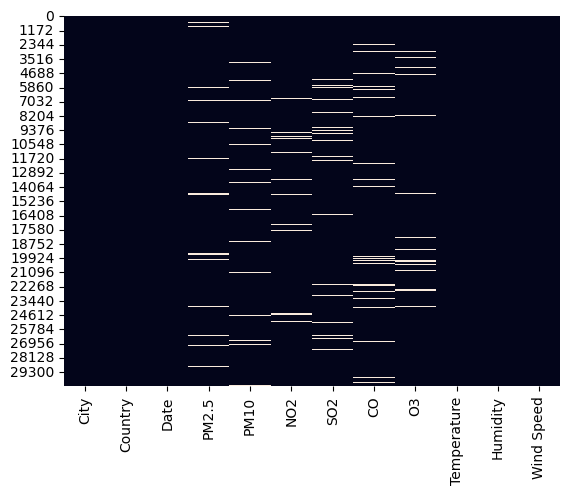

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_raw.isnull(), cbar=False)
plt.show()

**What we found:**
- A total of 10495 duplicate rows were identified in the dataset.

### A1.5 Column with Wrong Inferred dtype

In [8]:
# Convert to table format
wrong_dtype = df_raw[["City", "Country", "Date"]].dtypes.reset_index()
wrong_dtype.columns = ["Column", "Inferred dtype"]

wrong_dtype

,Column,Inferred dtype
0,City,object
1,Country,object
2,Date,object


### Justification for A1.5
The following columns `City`, `Country`, and `Date`were identified as having incorrect inferred data types and require conversion to ensure accurate and efficient analysis.


### A1.6 Column with Corrected inferred dtype for Variable Classification purpose

#### Issue 1: Incorrect Data Type for Date
- The `Date` variable is stored as an object instead of a datetime type.
- This prevents proper time-based analysis and must be corrected.

In [9]:
#Correct the data type for data
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce") # errors="coerce" to safe handling any invalid dates
#Show before and after
print("Before:", df_raw["Date"].dtype)
print("After :", df_clean["Date"].dtype)

Before: object
After : datetime64[ns]


In [10]:
#Check 
df_clean["Date"].isna().sum()

np.int64(0)

In [11]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day

#Show the cleaned output for date
df_clean[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2023-04-10,2023,4,10
1,2023-04-22,2023,4,22
2,2023-10-27,2023,10,27
3,2023-06-10,2023,6,10
4,2023-07-23,2023,7,23


#### After Conversion 
- The `Date` variable was initially stored as an `object` dtype.
- It was converted to datetime format using `pd.to_datetime()` to enable chronological analysis such as `Year`, `Month`, and`Day`.
- No missing or invalid date values were detected which indicating that no significant conversion errors and can proceed for variable classification.

#### Issue 2: Data Type Improvement for `City` and `Country`
- The `City` and `Country` variables are stored as an object instead of a category type.
- While this is acceptable for string data, they were converted to categorical types to improve memory efficiency and better reflect their nominal categorical nature.

In [12]:
df_clean["City"] = df_clean["City"].astype("category")
df_clean["Country"] = df_clean["Country"].astype("category")
df_clean[["City", "Country"]].dtypes

City       category
Country    category
dtype: object

#### After convertion 
- The `City` and `Country` variables were converted from `object` to `categorical` dtype to improve memory efficiency and better reflect their nominal categorical nature.
- The conversion was successful and can proceed for variable classification.

---
## A2 Variable Classification

### A2.1 Additional Variable Transformations

#### Issue 3: Negative Temperature Values
- The `Temperature` variable includes negative values.
- While negative temperatures are valid in some geographical regions, they may be unrealistic depending on the location and context of the dataset.
- These values should be verified to ensure they are not data entry errors or unit inconsistencies (e.g., Celsius vs Kelvin).

In [13]:
#Check negative temperature
df_raw[df_raw["Temperature"] < 0]

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
2,Berlin,Germany,10/27/2023,52.030,181.800,45.050,30.120,0.960,155.610,-4.090,96.900,2.490
5,Johannesburg,South Africa,7/25/2023,119.390,148.610,38.320,21.480,1.790,96.780,-2.620,89.280,9.270
14,London,UK,3/23/2023,21.330,190.160,26.620,40.190,2.630,14.070,-8.780,44.950,2.390
15,Seoul,South Korea,6/5/2023,79.710,195.270,91.260,NaN,1.240,NaN,-6.260,58.000,1.090
17,Beijing,China,4/3/2023,105.580,148.880,95.050,39.390,2.380,170.410,-5.820,29.380,13.340
...,...,...,...,...,...,...,...,...,...,...,...,...
30421,Los Angeles,USA,9/1/2023,64.880,173.950,73.250,NaN,9.190,192.190,-3.570,47.090,6.230
30427,NEW YORK,USA,11/26/2023,105.260,62.740,17.200,44.340,1.040,49.280,-4.520,82.350,11.780
30429,Berlin,Germany,7/14/2023,141.170,173.070,21.120,28.460,1.880,183.970,-5.970,11.950,13.200
30430,Sydney,Australia,8/12/2023,59.760,74.140,39.800,25.540,7.720,NaN,-1.260,12.270,17.070


In [14]:
# Define classification functions for temperature
def temp_category(temp):
    if temp < 10:
        return "Cold"
    elif temp <= 28:
        return "Neutral"
    else:
        return "Hot"

df_clean["Temp_Category"] = df_clean["Temperature"].apply(temp_category)

#Clean view
df_clean["Temp_Category"] = pd.Categorical(
    df_clean["Temp_Category"],
    categories=["Cold", "Neutral", "Hot"],
    ordered=True
)

#Show result
df_clean[["Temperature", "Temp_Category"]].head()

#Step 5: View result 
[
    df_clean[["Temperature", "Temp_Category"]].head(),
    df_clean["Temp_Category"].value_counts()
]

[   Temperature Temp_Category
 0       27.460       Neutral
 1       10.580       Neutral
 2       -4.090          Cold
 3       17.410       Neutral
 4       13.110       Neutral,
 Temp_Category
 Cold       12325
 Neutral    10936
 Hot         7189
 Name: count, dtype: int64]

In [15]:
# Determmine the temperature type
df_clean["Temperature"].describe()

count   30450.000
mean       14.801
std        14.487
min       -10.000
25%         2.020
50%        14.660
75%        27.230
max        40.000
Name: Temperature, dtype: float64

#### Justification for Issue 3:
- Negative temperature values were identified and retained because it may represent valid observations depending on geographic context.
- Instead to remove the negative values, we created a `Temp_Category` with 3 different threshold such as `Hot`,`Cold`, and `Neutral` to support our data analysis.
- The descriptive statistics show the temperature values range from -10 to 40, which looks realistic for everyday weather conditions in Celsius.
- Since there are negative values, this also confirms that the data is **NOT** recorded in Kelvin as it represented a absolute scale.

#### Issue 4: Lack of AQI Category Classification
- The dataset does not include categorical air quality classifications (e.g., “Good”, “Moderate”, “Unhealthy”) for pollutant variables such as `PM2.5` and `PM10`.
- Without defined thresholds, it is not possible to directly interpret air quality levels.
- For meaningful analysis, standard AQI breakpoints should be applied to derive categorical variables, enabling better interpretation and comparison.

In [16]:
#Step 1: Define classification functions for both AQI
def classify_pm25(pm25):
    if pm25 <= 5:
        return 1
    elif pm25 <= 15:
        return 2
    elif pm25 <= 25:
        return 3
    elif pm25 <= 50:
        return 4
    elif pm25 <= 100:
        return 5
    else:
        return 6

def classify_pm10(pm10):
    if pm10 <= 15:
        return 1
    elif pm10 <= 45:
        return 2
    elif pm10 <= 75:
        return 3
    elif pm10 <= 150:
        return 4
    elif pm10 <= 250:
        return 5
    else:
        return 6


#Step 2: Apply classification
df_clean["PM25_Level"] = df_clean["PM2.5"].apply(classify_pm25)
df_clean["PM10_Level"] = df_clean["PM10"].apply(classify_pm10)


#Step 3: Combine (with worst cases)
df_clean["AQI_Level"] = df_clean[["PM25_Level", "PM10_Level"]].max(axis=1)


#Step 4: Map to category labels
labels = {
    1: "Very Good",
    2: "Good",
    3: "Moderate",
    4: "Unhealthy",
    5: "Very Unhealthy",
    6: "Hazardous"
}
df_clean["AQI_Category"] = df_clean["AQI_Level"].map(labels)

#Step 5: Change type from object to category as ordinal order
df_clean["AQI_Category"] = pd.Categorical(
    df_clean["AQI_Category"],
    categories=[
        "Very Good",
        "Good",
        "Moderate",
        "Unhealthy",
        "Very Unhealthy",
        "Hazardous"
    ],
    ordered=True
)
#Step 5: View result 
[
    df_clean[["PM2.5", "PM10", "AQI_Category"]].head(),
    df_clean["AQI_Category"].value_counts()
]

[    PM2.5    PM10    AQI_Category
 0 127.510 175.100       Hazardous
 1  93.840  34.190  Very Unhealthy
 2  52.030 181.800  Very Unhealthy
 3 110.300     NaN       Hazardous
 4 120.240  48.980       Hazardous,
 AQI_Category
 Hazardous         12649
 Very Unhealthy    11515
 Unhealthy          4914
 Moderate           1015
 Good                357
 Very Good             0
 Name: count, dtype: int64]

#### Justification for Issue 4:
> A categorical AQI variable was created from PM2.5 values using standard thresholds to improve interpretability.
- Air quality categories `AQI_Category` were derived using both `PM2.5` and `PM10` concentrations based on thresholds aligned with WHO Air Quality Guidelines.
- Each pollutant was first classified into risk levels such as `Very Good`,`Good`, `Moderate`, `Unhealthy`, `Very Unhealthy`, `Hazardous`  and the overall air quality category was determined using the maximum (worst case) level.
- This approach reflects real-world air quality assessment practices, where the most hazardous pollutant determines overall risk.
- The resulting categories provide a more comprehensive and health-relevant interpretation of air quality conditions.

### A2.2 Classification Table

In [17]:
# Step 1: Create classification table
classification = pd.DataFrame({
    "Variable": [
        "City", "Country", "Date",
        "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
        "Temperature", "Humidity", "Wind Speed",
        "PM25_Level", "PM10_Level", "AQI_Level", "AQI_Category",
        "Year", "Month", "Day"
    ],

    "Measurement Type": [
        "Nominal categorical", "Nominal categorical", "Continuous (temporal)",
        "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical",
        "Continuous numerical", "Continuous numerical", "Continuous numerical",
        "Ordinal categorical", "Ordinal categorical", "Ordinal categorical", "Ordinal categorical",
        "Discrete numerical", "Discrete numerical", "Discrete numerical"
    ],

    "Role": [
        "Identifier", "Identifier", "Feature",
        "Feature", "Feature", "Feature", "Feature", "Feature", "Feature",
        "Feature", "Feature", "Feature",
        "Derived", "Derived", "Derived", "Derived",
        "Derived", "Derived", "Derived"
    ],

    "Summary Statistic": [
        "Mode", "Mode", "Min/Max",
        "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median",
        "Mean/Median", "Mean/Median", "Mean/Median",
        "Frequency", "Frequency", "Frequency", "Frequency",
        "Mode", "Mode", "Mode"
    ],

    "Visualisation": [
        "Bar chart", "Bar chart", "Line plot",
        "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot",
        "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot",
        "Bar chart", "Bar chart", "Bar chart", "Bar chart",
        "Bar chart", "Bar chart", "Bar chart"
    ]
})

# Step 2: Add Pandas dtype automatically (safe method)
classification["Pandas dtype"] = df_clean[classification["Variable"]].dtypes.values

# Step 3: Reorder columns (optional but cleaner)
classification = classification[
    ["Variable", "Pandas dtype", "Measurement Type", "Role", "Summary Statistic", "Visualisation"]
]

# Step 4: Display nicely
classification.style.set_caption("Variable Classification Table")

,Variable,Pandas dtype,Measurement Type,Role,Summary Statistic,Visualisation
0,City,category,Nominal categorical,Identifier,Mode,Bar chart
1,Country,category,Nominal categorical,Identifier,Mode,Bar chart
2,Date,datetime64[ns],Continuous (temporal),Feature,Min/Max,Line plot
3,PM2.5,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
4,PM10,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
5,NO2,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
6,SO2,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
7,CO,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
8,O3,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
9,Temperature,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot


### Justification for A2.2

> Overall, this classification ensures that appropriate statistical methods and visualisations are applied, improving the accuracy and interpretability of the analysis.

---
## A3 Missing Data Diagnosis

### A3.1 Misssing Data Pattern - Numerical summary

In [18]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

missing_summary

,Missing Count,Missing %
City,0,0.000
Country,0,0.000
Date,0,0.000
PM2.5,1552,5.097
PM10,1561,5.126
NO2,1593,5.232
SO2,1475,4.844
CO,1496,4.913
O3,1600,5.255
Temperature,0,0.000


### Justification for A3.1 ###
- Missing data analysis shows that pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`) contain approximately 4.8% to 5.3% missing values, while remaining variables have no missing observations.

### A3.2 Visualization - Missing Data Pattern

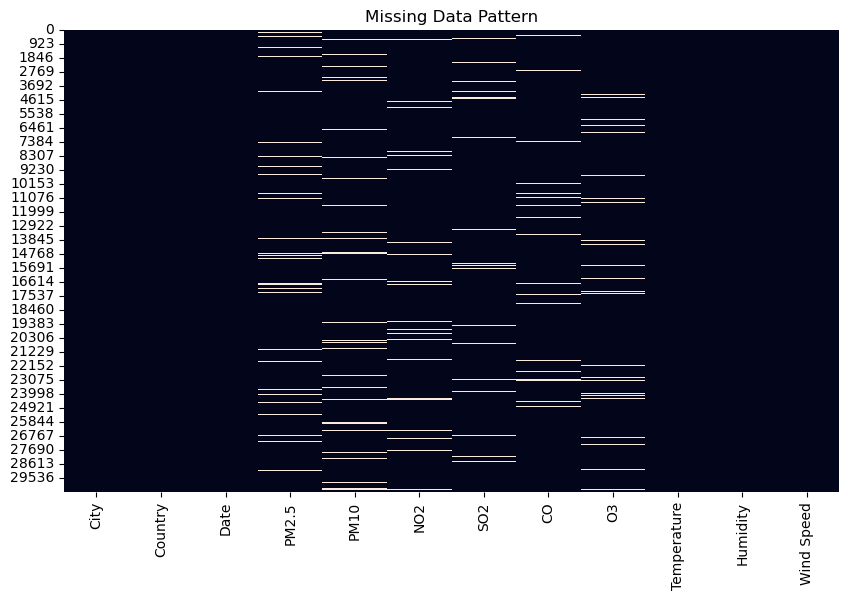

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

#### What we found ####
- The heatmap shows that missing values are primarily concentrated within the air pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`), while other variables such as `Temperature`, `Humidity`, and `Wind Speed` remain complete. 

- The missing values appear as scattered gaps across different observations rather than forming large continuous blocks. The missing values do not follow any obvious pattern.

- Overall, the pattern is more consistent with **Missing at Random (MAR)**.

### A3.3 Classify missingness (MCAR / MAR / MNAR)

In [20]:
print("Missing < 5% (excluding 0):")
print(missing_summary[(missing_summary["Missing %"] > 0) & (missing_summary["Missing %"] < 5)])

print("\nMissing ≥ 5%:")
print(missing_summary[missing_summary["Missing %"] >= 5])

Missing < 5% (excluding 0):
     Missing Count  Missing %
SO2           1475      4.844
CO            1496      4.913

Missing ≥ 5%:
       Missing Count  Missing %
PM2.5           1552      5.097
PM10            1561      5.126
NO2             1593      5.232
O3              1600      5.255


#### Justification for A3.3

- The missingness pattern varies across variables and is concentrated in pollutant measurements.
- Variables such as `City`, `Country`, `Date`, `Temperature`, `Humidity`, and `Wind Speed` contain **no missing values** and therefore do not show any missingness mechanism.
- Variables such as `SO2` and `CO` show **less than 5% missing values**.
- `PM2.5`, `PM10`, `NO2`, `O3` exhibit **more than 5% missing values**.
- The missing values are scattered across observations rather than forming clear or continuous blocks.

### A3.4 Compare handling strategies - for `PM2.5`

In [21]:
# Method 1: Listwise deletion (PM2.5 only)
pm25_drop = df_clean["PM2.5"].dropna()

mean_drop = pm25_drop.mean()
std_drop = pm25_drop.std()

# Method 2: Median imputation
pm25_impute = df_clean["PM2.5"].copy()

median_value = pm25_impute.median()
pm25_impute = pm25_impute.fillna(median_value)

mean_impute = pm25_impute.mean()
std_impute = pm25_impute.std()

# Compare results
print("Listwise Deletion → Mean:", mean_drop, "Std:", std_drop)
print("Median Imputation → Mean:", mean_impute, "Std:", std_impute)

Listwise Deletion → Mean: 77.65102740674094 Std: 42.01175009093976
Median Imputation → Mean: 77.68206600985222 Std: 40.92728736407015


### Justification for A3.4 ###
> The analysis is conducted on the cleaned dataset (df_clean) to ensure consistency after preprocessing.

- Listwise deletion reduces the dataset size and may introduce bias if missingness is not completely random.
- Median imputation preserves all observations and provides a robust estimate of central tendency.
- Both methods produce similar mean values, but median imputation results in a slightly lower standard deviation. This is because imputing with the median reduces variability in the dataset by replacing them with a central value.
- Therefore, median imputation is preferred as it retains all data while providing stable results.

### A3.5 Data Cleaning

#### Good structral quality, but need to improve 
- The dataset demonstrates generally good structural quality and is suitable for statistical analysis.
- It contains a sufficient number of observations and well-defined variables.
- Most numerical variables are correctly typed and key contextual variables such as `City` and `Country` are complete.
- However, several data quality issues necessary to conduct a data preprossesing before the analysis.

In [22]:
summary_table = pd.DataFrame({
    "Aspect": ["Rows", "Columns", "Duplicate Rows", "Missing Values"],
    "Observation": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.duplicated().sum(),
        "Present (~5% in pollutant variables)"
    ]
})

summary_table

,Aspect,Observation
0,Rows,30450
1,Columns,12
2,Duplicate Rows,10495
3,Missing Values,Present (~5% in pollutant variables)


### A3.5.1 Key Data Quality Issues

#### Issues 5: Duplicate and Near-Duplicate Rows
- The dataset includes duplicate and near-duplicate observations.
- These duplicates can bias statistical summaries by over-representing certain records.
- Removing duplicate rows is necessary to ensure each observation contributes equally to the analysis.

In [23]:
#Step 1: Count duplicates
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows (excluding first occurrence):", duplicate_count)

Duplicate rows (excluding first occurrence): 10495


In [24]:
# Step 2: Show ALL duplicate rows (both original + repeated)
duplicates_full = df_clean[df_clean.duplicated(keep=False)].copy()
duplicates_full = duplicates_full.sort_values(by=["City", "Date"]).reset_index(drop=True)
duplicates_full["Duplicate Flag"] = "Yes"
duplicates_full.head(10)

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,...,Wind Speed,Year,Month,Day,Temp_Category,PM25_Level,PM10_Level,AQI_Level,AQI_Category,Duplicate Flag
0,BANGKOK,Thailand,2023-03-25,75.500,157.400,79.920,49.200,7.990,77.180,20.770,...,3.140,2023,3,25,Neutral,5,5,5,Very Unhealthy,Yes
1,BANGKOK,Thailand,2023-03-25,75.500,157.400,79.920,49.200,7.990,77.180,20.770,...,3.140,2023,3,25,Neutral,5,5,5,Very Unhealthy,Yes
2,BANGKOK,Thailand,2023-05-07,76.490,114.470,72.370,21.860,0.640,103.550,8.030,...,11.080,2023,5,7,Cold,5,4,5,Very Unhealthy,Yes
3,BANGKOK,Thailand,2023-05-07,76.490,114.470,72.370,21.860,0.640,103.550,8.030,...,11.080,2023,5,7,Cold,5,4,5,Very Unhealthy,Yes
4,BANGKOK,Thailand,2023-06-05,82.040,109.580,97.120,9.640,8.530,46.720,3.030,...,3.350,2023,6,5,Cold,5,4,5,Very Unhealthy,Yes
5,BANGKOK,Thailand,2023-06-05,82.040,109.580,97.120,9.640,8.530,46.720,3.030,...,3.350,2023,6,5,Cold,5,4,5,Very Unhealthy,Yes
6,BANGKOK,Thailand,2023-07-20,27.080,139.490,67.300,10.860,1.610,85.500,21.440,...,19.050,2023,7,20,Neutral,4,4,4,Unhealthy,Yes
7,BANGKOK,Thailand,2023-07-20,27.080,139.490,67.300,10.860,1.610,85.500,21.440,...,19.050,2023,7,20,Neutral,4,4,4,Unhealthy,Yes
8,BANGKOK,Thailand,2023-08-12,148.440,193.880,24.880,7.260,9.120,10.370,36.000,...,11.480,2023,8,12,Hot,6,5,6,Hazardous,Yes
9,BANGKOK,Thailand,2023-08-12,148.440,193.880,24.880,7.260,9.120,10.370,36.000,...,11.480,2023,8,12,Hot,6,5,6,Hazardous,Yes


In [25]:
# Step 3: Remove duplicates
df_clean = df_clean.drop_duplicates()

In [26]:
# Step 4: Verify removal
duplicate_after = df_clean.duplicated().sum()
print("\nDuplicate rows AFTER removal:", duplicate_after)


Duplicate rows AFTER removal: 0


In [27]:
# Step 5: Show dataset shape change
print("\nDataset shape BEFORE:", df_raw.shape)
print("Dataset shape AFTER :", df_clean.shape)


Dataset shape BEFORE: (30450, 12)
Dataset shape AFTER : (19955, 20)


#### After clean the duplicate 
- A sample of duplicate rows is presented to provide visual evidence of repeated observations within the dataset.
- Displaying both the original and duplicated entries allows verification that the rows are identical across all variables.
- This supports the decision to remove duplicates, as their presence would otherwise bias statistical summaries by over-representing certain observations.
- The table also demonstrates that duplicate detection was performed after standardisation, ensuring that inconsistencies in formatting did not mask near-duplicate records.

#### Issues 6 : Missing Values
- Several pollutant variables (PM2.5, PM10, NO2, and O3) contain approximately 5% missing values. 
- The missingness appears scattered and is most consistent with **Missing at Random (MAR)**.This level of missingness is moderate and may introduce bias if not handled properly.
- **Median imputation** is preferred due to the skewed distribution of environmental data.

In [28]:
#Median imputation to fill in the missing values 
missing_before = df_clean["PM2.5"].isnull().sum()
print("Missing before:", missing_before)

#Assign a list and use for loop
var_to_impute = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

for col in var_to_impute:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

missing_after = df_clean["PM2.5"].isnull().sum()

print("Missing after:", missing_after)

#Result data clean for no missing value
df_clean[var_to_impute].isnull().sum()

Missing before: 1491
Missing after: 0


PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
dtype: int64

#### After median imputation
- Missing values in pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`) were handled simultaneously using median imputation.
- This approach ensures consistency across variables and is appropriate given the skewed distribution of environmental data.
    

#### Issue 7: Inconsistent Variables Formatting
- Inconsistent formatting is present in variables such as `Country` and `City`, including differences in type, capitalisation, spacing, and naming conventions (e.g., "USA" vs "usa").
- This can lead to incorrect grouping and aggregation.
- Standardisation is required before analysis.

In [29]:
# Standardisation

print("Before unique City:", df_raw["City"].nunique())

df_clean["City"] = df_clean["City"].str.strip().str.lower()

print("After unique City :", df_clean["City"].nunique())

df_clean["City"].value_counts().head(10)

Before unique City: 120
After unique City : 20


City
johannesburg    1071
mumbai          1062
dubai           1049
toronto         1047
berlin          1031
seoul           1027
madrid          1027
cairo           1011
bangkok         1009
sydney          1007
Name: count, dtype: int64

In [30]:
# Before Standardisation for City 
list(df_raw["City"].unique())
df_raw["City"].unique().tolist()

['Johannesburg',
 'Istanbul',
 'Berlin',
 'SYDNEY',
 'Dubai',
 'Los Angeles',
 'Mumbai',
 'Beijing',
 'Paris',
 'New York',
 'London',
 'Seoul   ',
 'Toronto',
 'Tokyo',
 'london',
 'Mexico City',
 'Madrid',
 'Seoul',
 'Bangkok',
 'New York   ',
 'Rio de Janeiro',
 'MOSCOW',
 'BERLIN',
 'BANGKOK',
 'Moscow',
 'MADRID',
 'johannesburg',
 'MEXICO CITY',
 'Berlin   ',
 'LONDON',
 'tokyo',
 'Paris   ',
 'berlin',
 'istanbul',
 'Cairo',
 'rio de janeiro',
 'Mexico City   ',
 'bangkok',
 'cairo',
 'dubai',
 'new york',
 'toronto',
 'los angeles',
 'mexico city',
 'RIO DE JANEIRO',
 'BEIJING',
 'Sydney',
 'sydney',
 'ISTANBUL',
 'Beijing   ',
 'CAIRO',
 'MUMBAI',
 'DUBAI',
 'madrid',
 'Sydney   ',
 'NEW YORK   ',
 'beijing',
 'moscow',
 'JOHANNESBURG',
 'Moscow   ',
 'TOKYO',
 'TORONTO',
 'PARIS',
 'LOS ANGELES',
 'SEOUL',
 'Cairo   ',
 'Rio de Janeiro   ',
 'mumbai',
 'new york   ',
 'MUMBAI   ',
 'Bangkok   ',
 'Johannesburg   ',
 'NEW YORK',
 'Los Angeles   ',
 'Madrid   ',
 'paris',
 'Ist

In [31]:
# After Standardisation for City 
list(df_clean["City"].unique())
df_clean["City"].unique().tolist()

['johannesburg',
 'istanbul',
 'berlin',
 'sydney',
 'dubai',
 'los angeles',
 'mumbai',
 'beijing',
 'paris',
 'new york',
 'london',
 'seoul',
 'toronto',
 'tokyo',
 'mexico city',
 'madrid',
 'bangkok',
 'rio de janeiro',
 'moscow',
 'cairo']

#### After standardization
- The `City` variable was standardised by removing whitespace and converting text to lowercase, reducing the number of unique categories and ensuring consistent grouping.

In [32]:
# Convert `City` from `object` to `category` type
df_clean["City"] = df_clean["City"].astype("category")

# Check dtype for `City` and `Country`
df_clean[["City", "Country"]].dtypes

City       category
Country    category
dtype: object

#### After covertion
- `City` and `Country` were treated as categorical variables.

#### Why convert?
- As `City` was initially stored as an `object` type, it was converted to a categorical type for analytical consistency.

---
## A4 Data Quality Narrative

#### Overall Dataset Quality

After going through a structured cleaning and validation process, the dataset can generally be adequate for statistical analysis. 

### A4.1 Overview of the Final Cleaned Dataset: `df_clean` 

In [33]:
# FINAL CLEANED DATASET (PREVIEW)
df_clean.head()
df_clean.info()

df_clean[[
    "City", "Country", "Date",
    "PM2.5", "PM10",
    "AQI_Category"
]].head
df_clean.head().style.set_caption("Final Cleaned Dataset (Preview)")

<class 'pandas.core.frame.DataFrame'>
Index: 19955 entries, 0 to 30449
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   City           19955 non-null  category      
 1   Country        19955 non-null  category      
 2   Date           19955 non-null  datetime64[ns]
 3   PM2.5          19955 non-null  float64       
 4   PM10           19955 non-null  float64       
 5   NO2            19955 non-null  float64       
 6   SO2            19955 non-null  float64       
 7   CO             19955 non-null  float64       
 8   O3             19955 non-null  float64       
 9   Temperature    19955 non-null  float64       
 10  Humidity       19955 non-null  float64       
 11  Wind Speed     19955 non-null  float64       
 12  Year           19955 non-null  int32         
 13  Month          19955 non-null  int32         
 14  Day            19955 non-null  int32         
 15  Temp_Category  19955 non

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,Year,Month,Day,Temp_Category,PM25_Level,PM10_Level,AQI_Level,AQI_Category
0,johannesburg,South Africa,2023-04-10 00:00:00,127.510000,175.100000,52.170000,13.020000,1.700000,196.410000,27.460000,51.140000,10.260000,2023,4,10,Neutral,6,5,6,Hazardous
1,istanbul,Turkey,2023-04-22 00:00:00,93.840000,34.190000,79.490000,44.540000,5.180000,183.620000,10.580000,30.480000,14.450000,2023,4,22,Neutral,5,2,5,Very Unhealthy
2,berlin,Germany,2023-10-27 00:00:00,52.030000,181.800000,45.050000,30.120000,0.960000,155.610000,-4.090000,96.900000,2.490000,2023,10,27,Cold,5,5,5,Very Unhealthy
3,sydney,Australia,2023-06-10 00:00:00,110.300000,103.195000,77.440000,9.780000,6.540000,18.980000,17.410000,64.790000,12.770000,2023,6,10,Neutral,6,6,6,Hazardous
4,dubai,UAE,2023-07-23 00:00:00,120.240000,48.980000,98.820000,6.270000,6.980000,133.940000,13.110000,31.610000,5.000000,2023,7,23,Neutral,6,3,6,Hazardous


In [34]:
# Check df_clean shape
print(f"Final cleaned dataset contains {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.")

Final cleaned dataset contains 19955 rows and 20 columns.


### After preprocessing, the dataset `df_clean` is cleaned and ready for descriptive statistical analysis in Task B.

---
# Task B 